In [3]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import find_closest_index_dt

import dateutil
from dateutil.parser import parse

In [4]:
start = '2023-01-03'
end = '2023-01-04'
time_clip = True
no_update = False
varnames_hfr = 'psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2'
varnames_lfr = 'psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2'
rfs_hfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_hfr', level='l3', no_update=no_update, varnames=varnames_hfr)
rfs_lfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_lfr', level='l3', no_update=no_update, varnames=varnames_lfr)
rfs_ch0_hfr = pyspedas.get('psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2')
rfs_ch0_lfr = pyspedas.get('psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2')
data_hfr = rfs_ch0_hfr.y
freq_hfr = rfs_ch0_hfr.v
times_hfr = rfs_ch0_hfr.times

data_lfr = rfs_ch0_lfr.y
freq_lfr = rfs_ch0_lfr.v
times_lfr = rfs_ch0_lfr.times

dyspec = data_hfr
t_fits = times_hfr
full_f_fits = np.concatenate((freq_lfr[0], freq_hfr[0]))
full_data = np.concatenate((data_lfr, data_hfr), axis = 1)

07-Oct-25 22:43:25: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
07-Oct-25 22:43:25: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
07-Oct-25 22:43:25: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
07-Oct-25 22:43:26: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
07-Oct-25 22:43:26: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
07-Oct-25 22:43:26: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf
07-Oct-25 22:43:26: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
07-Oct-25 22:43:26: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf


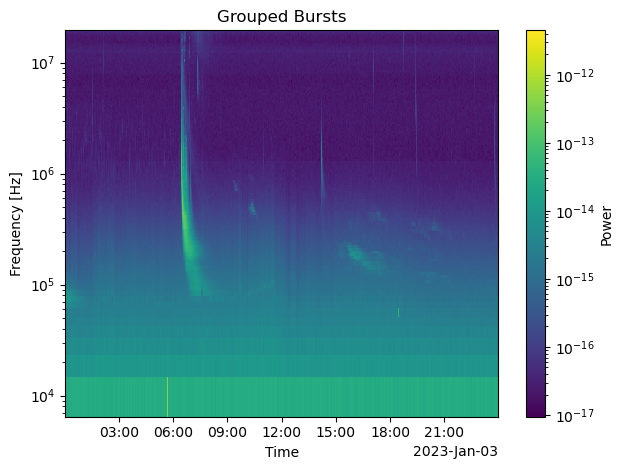

In [5]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

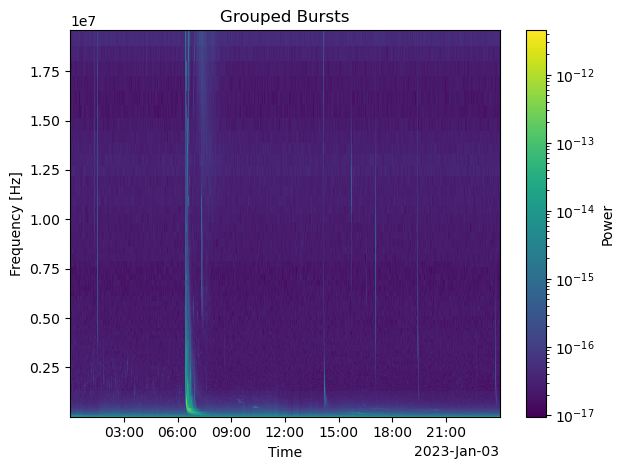

In [6]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
def binarization(full_data, ratio=1.5):
    """
    Make a binary map where a pixel is 1 if the current time-step value
    is larger than the previous time-step by a factor `ratio`.
      - full_data: (N_time, N_freq)
      - ratio: >1 to avoid noise-triggered flips (e.g., 1.05 = +5%)
      - use_log: if True, compare on log10 scale with an additive threshold
    """
    # comp = (full_data[1:, :] >= ratio * full_data[:-1, :])
    # comp2 = (full_data[1:, :] * ratio <= full_data[:-1, :])
    # both = np.logical_or(comp, comp2)
    log_data = np.log10(full_data)
    ratio = np.log10(ratio)
    comp = log_data[1:, :] - log_data[:-1, :] >= ratio
    comp2 = log_data[:-1, :] - log_data[1:, :] >= ratio
    both = np.logical_or(comp, comp2)
    

    bmap = np.zeros_like(full_data, dtype=np.uint8)
    bmap[1:, :] = both  # first row has no left/previous neighbor → 0
    return bmap

In [8]:
print(binarization(full_data))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


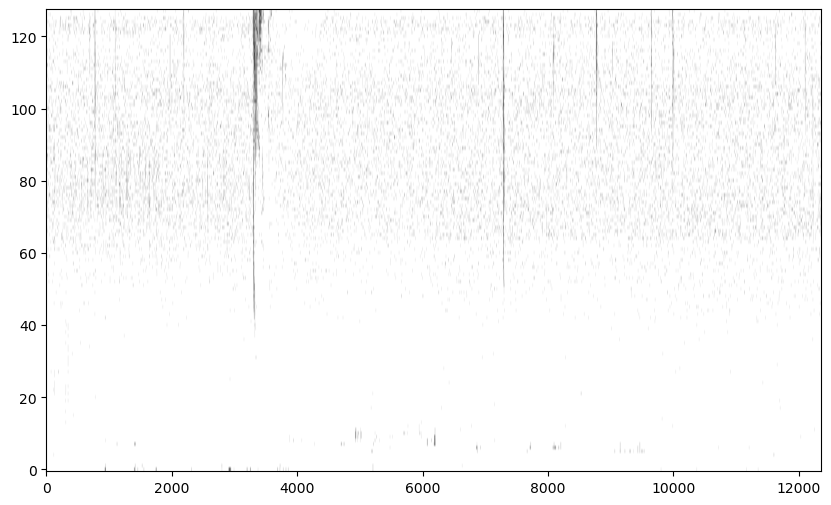

In [9]:
bmap = binarization(full_data)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

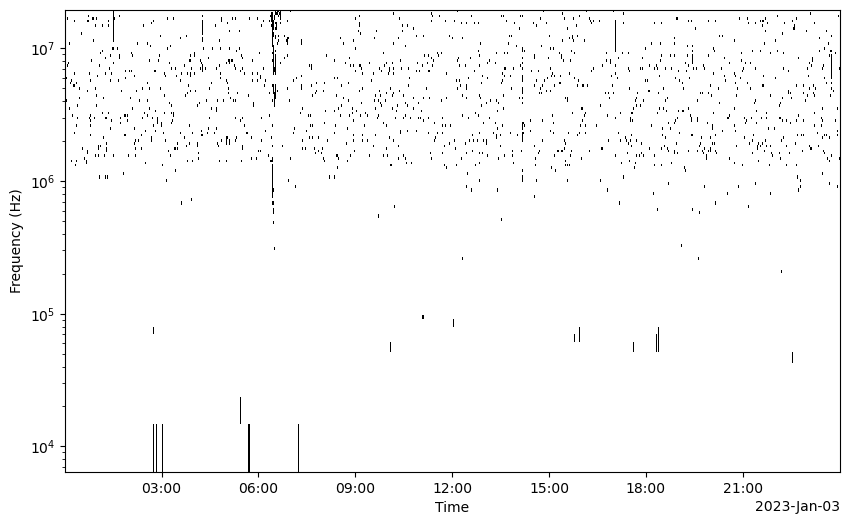

In [10]:
fig, ax = plt.subplots(figsize=(10,6))
pm = ax.pcolormesh(
    times_hfr, full_f_fits, bmap.T,
    shading='auto', cmap='gray_r', vmin=0, vmax=1
)
ax.set_xlabel('Time'); ax.set_ylabel('Frequency (Hz)')
ax.set_yscale('log')
plt.show()

In [11]:
def binarize_threshold(data, threshold=1e-14):
    """
    Make a binary map where pixels are 1 if power > threshold,
    otherwise 0.
    """
    return (data > threshold).astype(np.uint8)

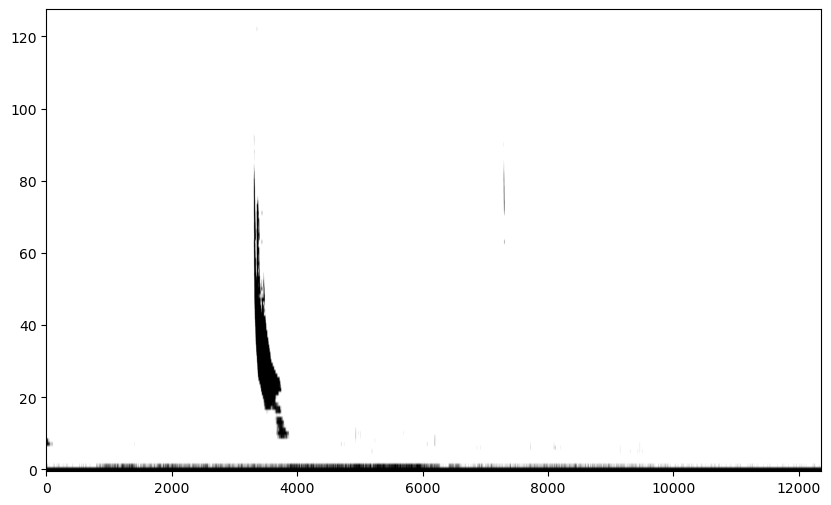

In [12]:
bmap_threshold = binarize_threshold(full_data)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_threshold.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

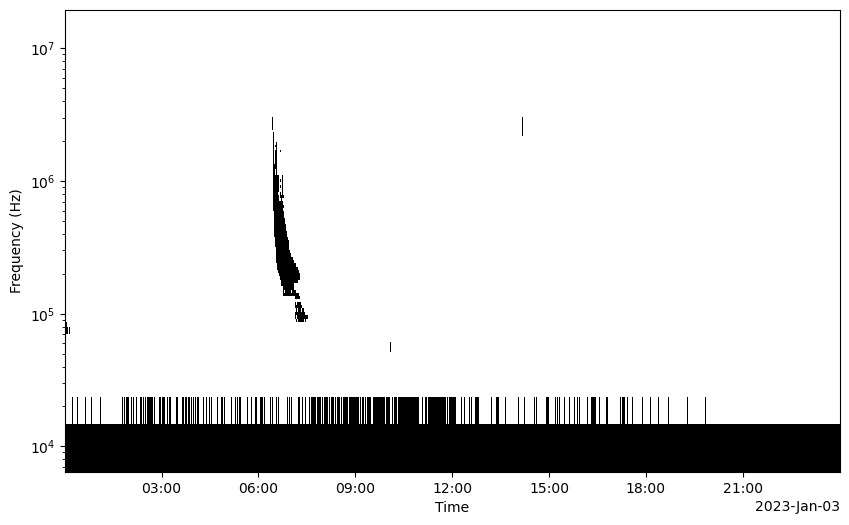

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
pm = ax.pcolormesh(times_hfr, full_f_fits, bmap_threshold.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')
ax.set_yscale('log')
plt.show()

In [14]:
full_data.shape

(12359, 128)

In [15]:
full_data[idx].shape

NameError: name 'idx' is not defined

In [21]:
repeated = np.tile(full_data[idx], (full_data.shape[0], 1))
repeated.shape

NameError: name 'idx' is not defined

NameError: name 'repeated' is not defined

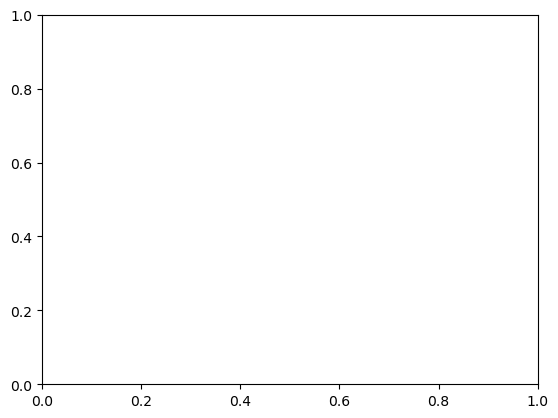

In [23]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, repeated.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
def binarization(data_fits_new,N_order=2,peak_r=2):
    # with high order local-max method 
    # original default arguments : N_order = 5
    # peak_r = 0.95
    bmap = np.ones_like(data_fits_new)
    N_pad = N_order
    local_max_arr = np.pad(data_fits_new,((N_pad,N_pad),(0,0)))
    for idx in range(N_pad-1):
        bmap=bmap* ((peak_r*local_max_arr[N_pad+idx+1:-N_pad+idx+1,:]<
                            local_max_arr[N_pad+idx:-N_pad+idx,:]) | 
                    (peak_r*local_max_arr[N_pad-idx-1:-N_pad-idx-1,:]<
                            local_max_arr[N_pad-idx:-N_pad-idx,:]) )
    return bmap

bmap = binarization(full_data)
bmap

array([[1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

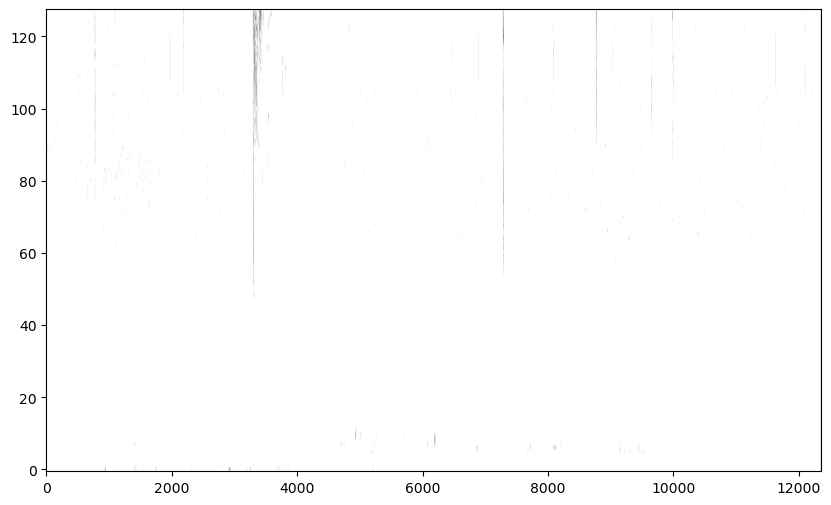

In [27]:
plt.figure(figsize=(10, 6))
plt.imshow(1-bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [29]:
def bmap_col_mean_loop(full_data, ratio = 0.6):
    time_num = full_data.shape[0]
    bmap = np.zeros_like(full_data)

    for i in range(time_num):
        col_avg = np.mean(full_data[i, :])
        col_std = np.std(full_data[i, :])
        bmap[i, :] = (full_data[i, :] > ratio * (col_avg + col_std))

    return bmap

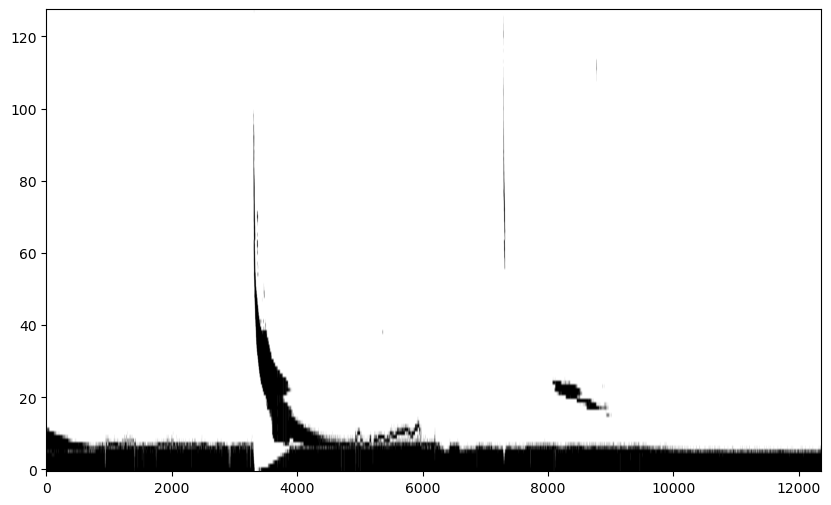

In [31]:
bmap_col_mean = bmap_col_mean_loop(full_data)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_col_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

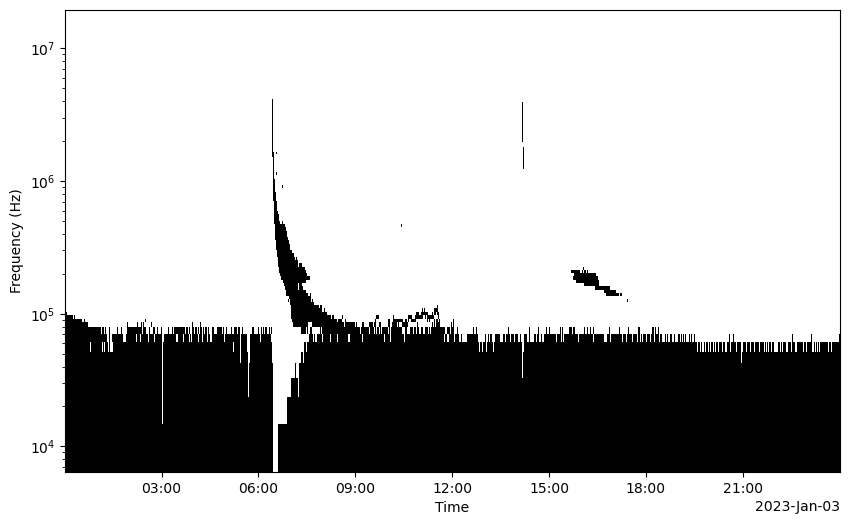

In [33]:
fig, ax = plt.subplots(figsize=(10,6))
pm = ax.pcolormesh(
    times_hfr, full_f_fits, bmap_col_mean.T,
    shading='auto', cmap='gray_r', vmin=0, vmax=1
)
ax.set_xlabel('Time'); ax.set_ylabel('Frequency (Hz)')
ax.set_yscale('log')
plt.show()

In [35]:
full_data.shape

(12359, 128)

In [37]:
full_data[1, :].shape

(128,)

In [39]:
def bmap_row_mean_loop(full_data, ratio=1.2):
    freq_num = full_data.shape[1]
    bmap = np.zeros_like(full_data)

    for i in range(freq_num):
        row_avg = np.mean(full_data[:, i])
        row_std = np.std(full_data[:, i])
        bmap[:, i] = (full_data[:, i] > ratio * (row_avg + row_std))

    return bmap

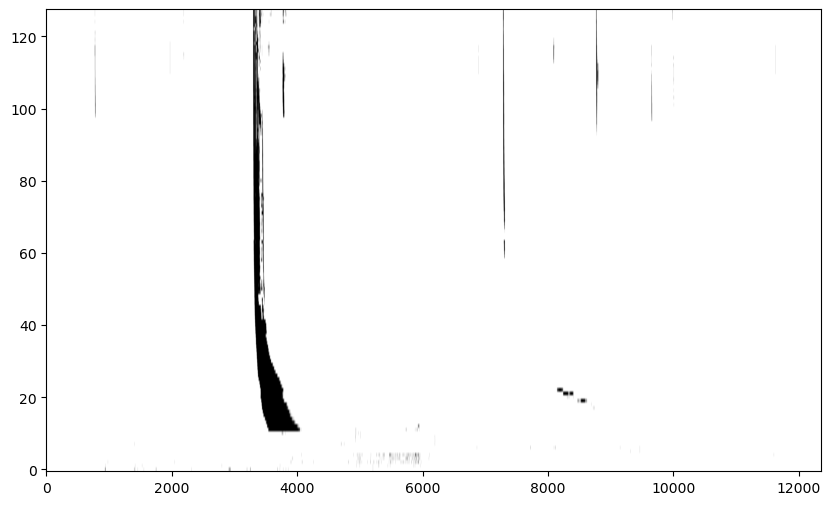

In [41]:
bmap_row_mean = bmap_row_mean_loop(full_data)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

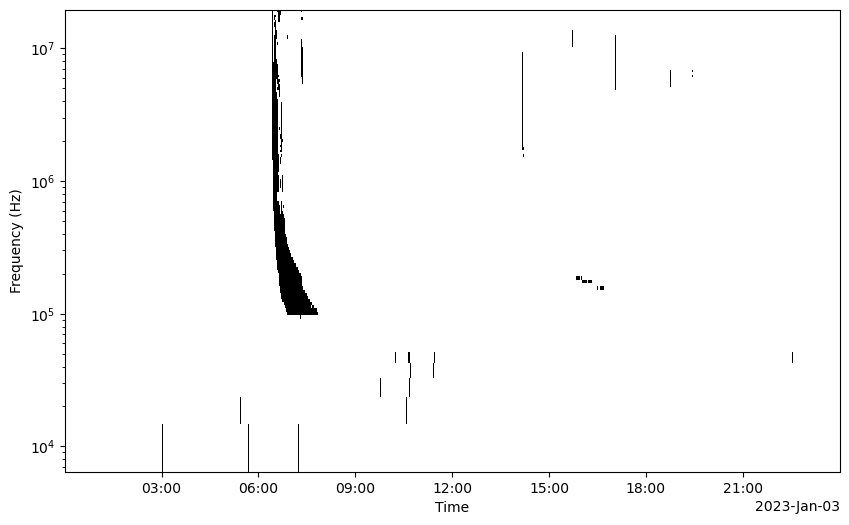

In [43]:
fig, ax = plt.subplots(figsize=(10,6))
pm = ax.pcolormesh(times_hfr, full_f_fits, bmap_row_mean.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')
ax.set_yscale('log')
plt.show()

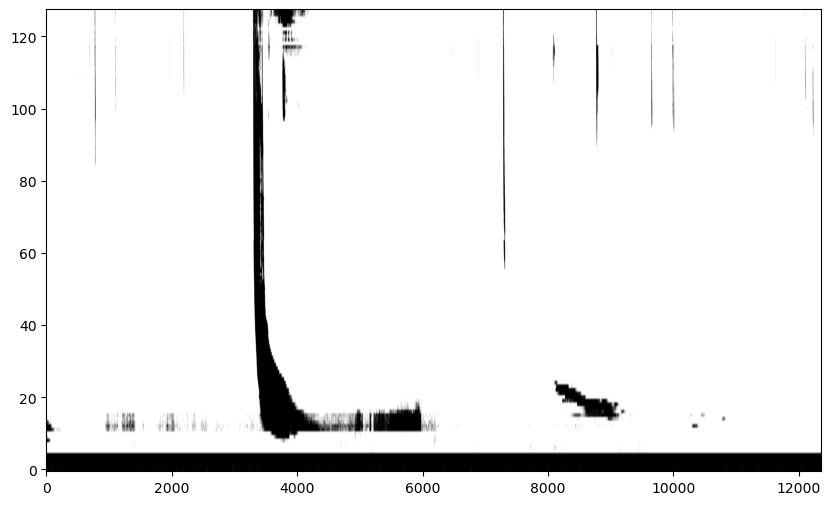

In [61]:
bmap_row_mean2 = bmap_row_mean_loop(full_data, ratio=0.5)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean2.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

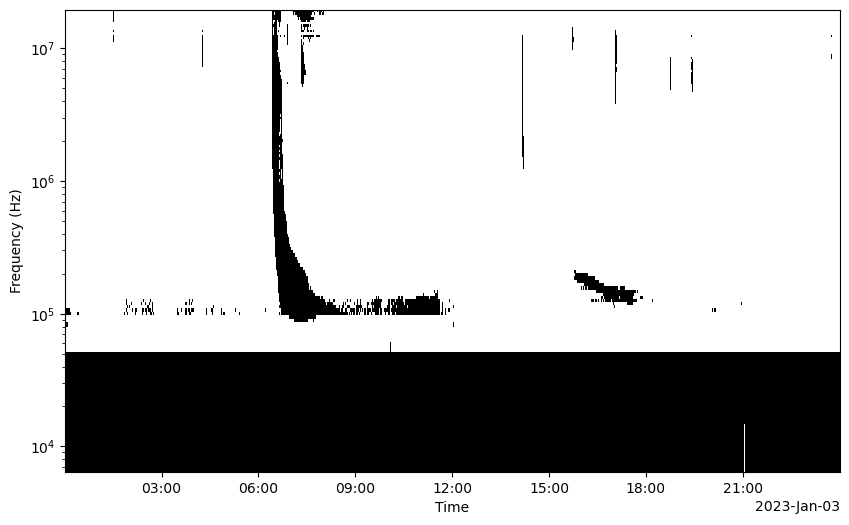

In [63]:
fig, ax = plt.subplots(figsize=(10,6))
pm = ax.pcolormesh(times_hfr, full_f_fits, bmap_row_mean2.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')
ax.set_yscale('log')
plt.show()

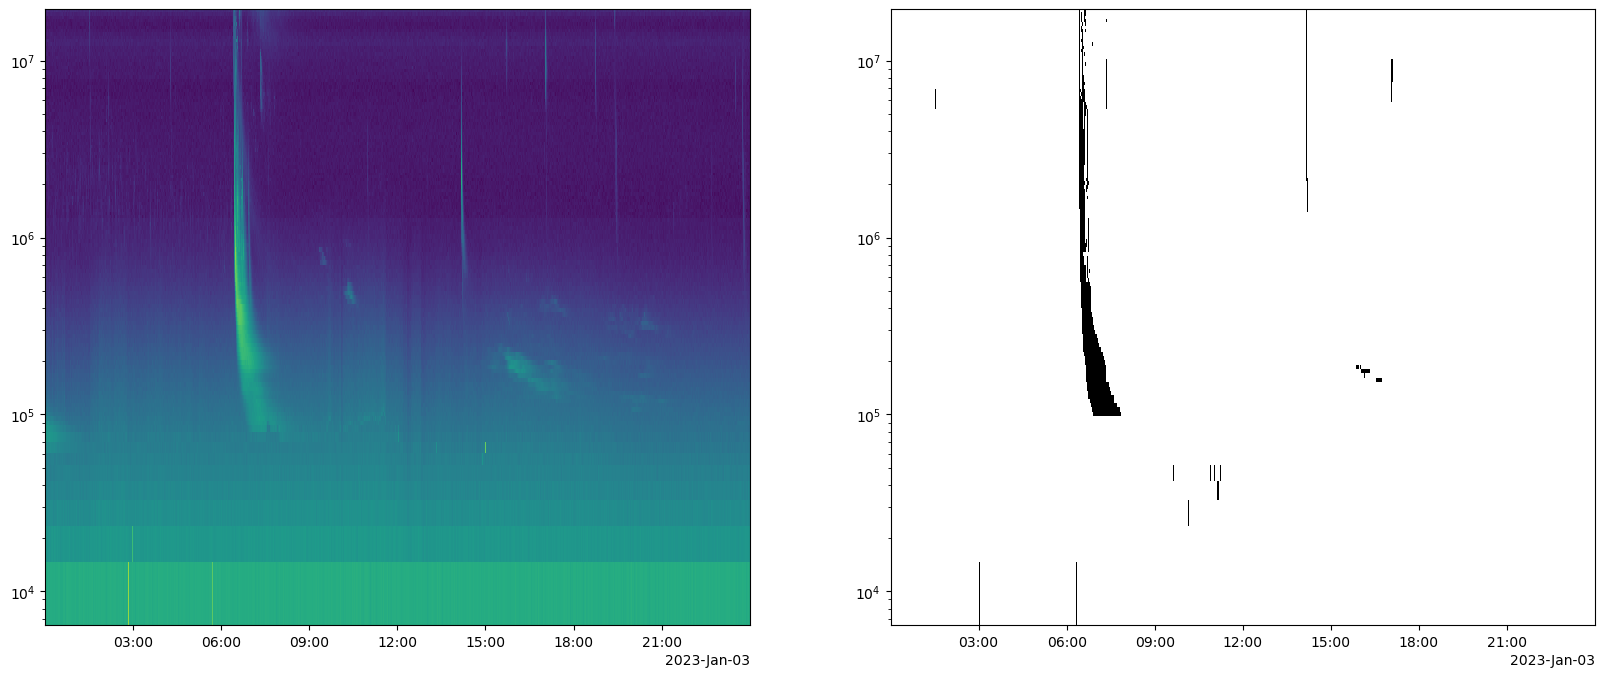

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
ax1.set_yscale('log')

ax2.pcolormesh(times_hfr, full_f_fits, bmap_row_mean.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
ax2.set_yscale('log')
plt.show()

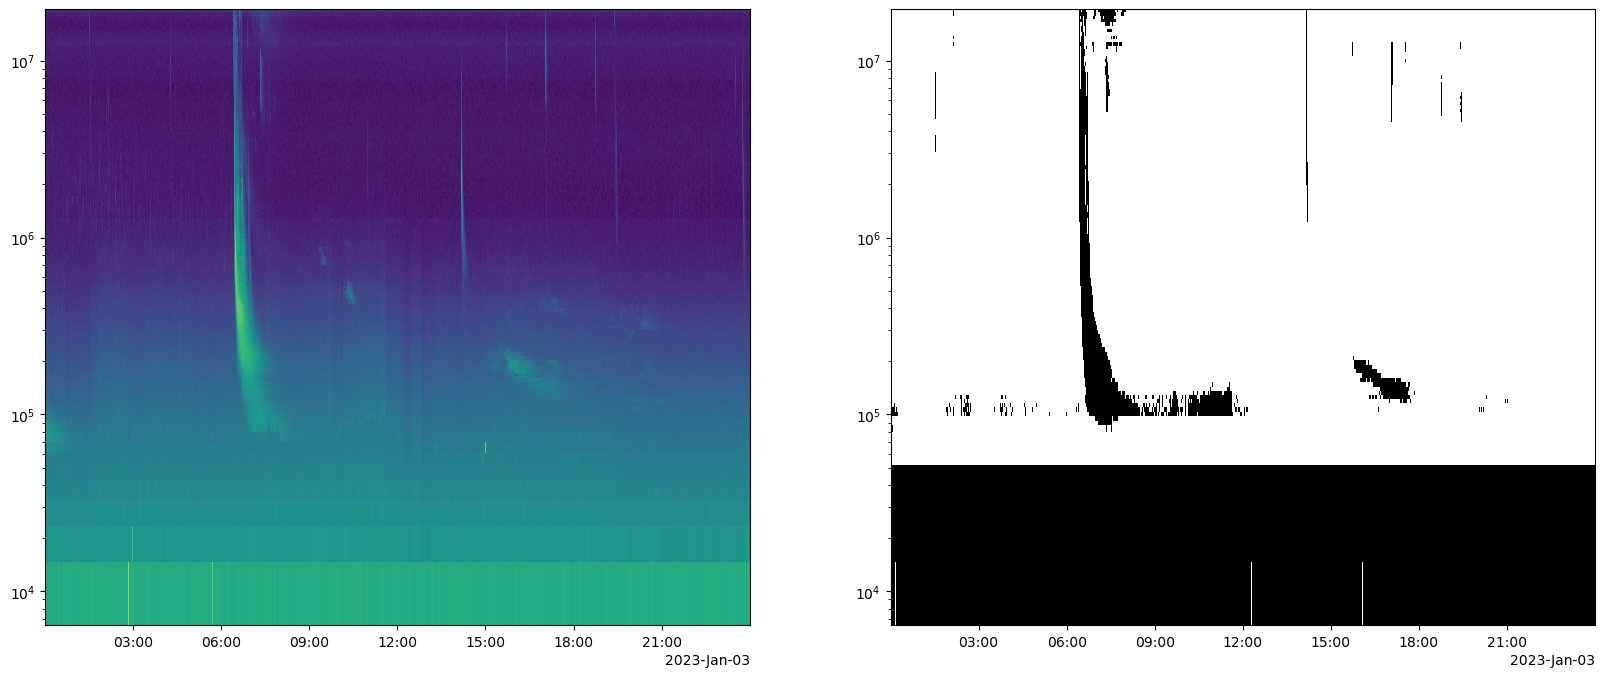

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
ax1.set_yscale('log')

ax2.pcolormesh(times_hfr, full_f_fits, bmap_row_mean2.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
ax2.set_yscale('log')
plt.show()

In [527]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    # trial 4
    threshold = 130
    line_gap = 110
    line_length = 110
    theta = np.deg2rad(np.linspace(45, 55, 120))
    
    # trial 3
    # threshold = 50
    # line_gap = 110
    # line_length = 110
    # theta = np.deg2rad(np.linspace(65, 75, 120))
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(bmap_row_mean, full_data)
lines

[((17, 3449), (127, 3339)),
 ((17, 3447), (127, 3337)),
 ((17, 3448), (127, 3338)),
 ((17, 3450), (127, 3340)),
 ((17, 3451), (127, 3341)),
 ((17, 3452), (127, 3342)),
 ((16, 3458), (126, 3348)),
 ((16, 3459), (126, 3349)),
 ((16, 3460), (126, 3350)),
 ((16, 3469), (127, 3358)),
 ((15, 3468), (127, 3356)),
 ((15, 3467), (127, 3355)),
 ((16, 3468), (126, 3358))]

In [521]:
norm = np.linalg.norm
def point_to_line_distance(p1,p2,p3):
    d = np.abs(norm(np.cross(p2-p1, p1-p3)))/norm(p2-p1)
    return d

def point_to_point_distance(p1,p2):
    return norm(p1-p2)

In [523]:
def line_grouping(lines,min_dist=3, threshmode=2): # pix
    """
    Parameters
    ----------
    lines : list
        list of lines detected by hough transform.
    min_dist : float, optional  # pix
        minimum distance between two lines to be grouped together.
    threshmode : int, optional
        DESCRIPTION. 1: only distance of point to line
                        2: distance of point to line and angle between lines
    """
    # group the detected lines into group in regard of events
    lines = sorted(lines, key=lambda i: (i[0][1]+i[1][1])/2)
    line_sets = [[lines[0]]]
    for idx,line in enumerate(lines[0:-1]):
        (A,B),(C,D) = np.array([lines[idx], lines[idx+1] ])

        # use the longer line as the reference
        l_AB = norm(A-B)
        l_CD = norm(C-D)
        if l_AB<l_CD:
            A,B,C,D = C,D,A,B
        
        # point to line distance
        Line_dist_thresh = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist
        Line_dist_thresh2 = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist*1.5

        # two lines segment not too far away
        Point_dist_thresh = np.min([point_to_point_distance(A,C),point_to_point_distance(A,D),
                                    point_to_point_distance(B,C),point_to_point_distance(B,D)])< np.max(
                                        [point_to_point_distance(A,B),point_to_point_distance(C,D)])
       
        if threshmode==1:
            final_thresh = Line_dist_thresh
        elif threshmode==2:
            final_thresh = Line_dist_thresh & Point_dist_thresh
        elif threshmode==3:
            if B[0]>C[0] and B[1]>C[1]:
                final_thresh = Line_dist_thresh2 & Point_dist_thresh

        if final_thresh:
            # the line join
            line_sets[len(line_sets)-1].append(lines[idx+1])
        else:
            # new set
            line_sets.append([lines[idx+1]])
    
    return line_sets

line_sets = line_grouping(lines)
line_sets

[[((17, 3447), (127, 3337)),
  ((17, 3448), (127, 3338)),
  ((17, 3449), (127, 3339)),
  ((17, 3450), (127, 3340)),
  ((17, 3451), (127, 3341)),
  ((17, 3452), (127, 3342))],
 [((16, 3458), (126, 3348)),
  ((16, 3459), (126, 3349)),
  ((16, 3460), (126, 3350))],
 [((15, 3467), (127, 3355)),
  ((15, 3468), (127, 3356)),
  ((16, 3468), (126, 3358)),
  ((16, 3469), (127, 3358))]]

<Figure size 1000x600 with 0 Axes>

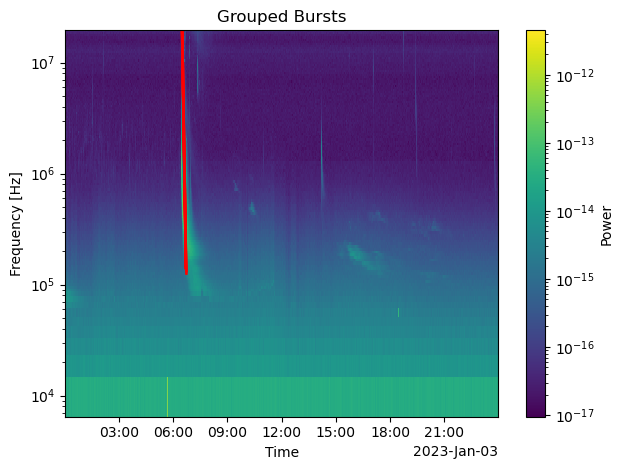

In [525]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for line_group in line_sets:
    for (x0, y0), (x1, y1) in line_group:
        t0, t1 = t_fits[y0], t_fits[y1]
        f0, f1 = full_f_fits[x0], full_f_fits[x1]
        # print(t0, t1, f0, f1)
        ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

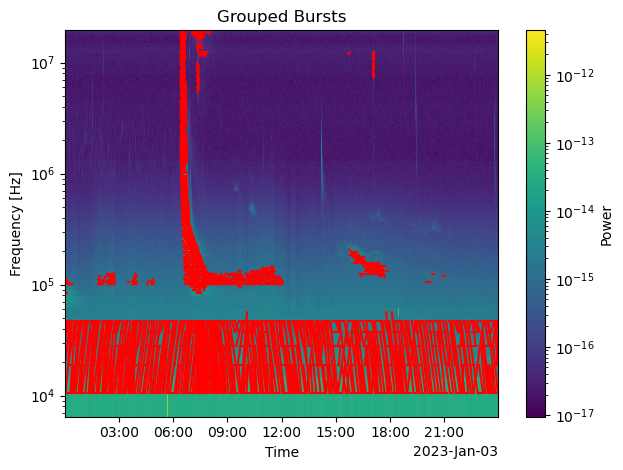

In [67]:
lines2 = hough_detect(bmap_row_mean2, full_data)
line_sets2 = line_grouping(lines2)

plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for line_group in line_sets2:
    for (x0, y0), (x1, y1) in line_group:
        t0, t1 = t_fits[y0], t_fits[y1]
        f0, f1 = full_f_fits[x0], full_f_fits[x1]
        # print(t0, t1, f0, f1)
        ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()